# Analisis Regresi Linear: Probabilitas Hujan vs ONI
**Dashboard Probabilitas Hujan NTT — 1985–2015**

Notebook ini mereproduksi analisis regresi dan korelasi yang sama persis dengan Tab 3 (Korelasi) di Streamlit dashboard.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

## 1. Konfigurasi (sama persis dengan app.py)

In [2]:
# ── Konfigurasi musim — identik dengan app.py ──
SEASON_ORDER  = ['JFM', 'AMJ', 'JAS', 'OND']
SEASON_COLORS = {
    'JFM': '#3b82f6',
    'AMJ': '#22c55e',
    'JAS': '#eab308',
    'OND': '#ec4899',
}
SEASON_MONTHS = {
    'JFM': 'Jan–Mar',
    'AMJ': 'Apr–Jun',
    'JAS': 'Jul–Sep',
    'OND': 'Okt–Des',
}

## 2. Load Data

In [3]:
# ── Load spasial_data.csv ──
# Ganti path sesuai lokasi file Anda
try:
    spasial = pd.read_csv('spasial_data.csv')
    spasial.columns = spasial.columns.str.strip()
    # Normalise nama kolom (sama dengan app.py)
    for c in spasial.columns:
        if c.lower() in ('season', 'musim'):
            spasial.rename(columns={c: 'Season'}, inplace=True)
    for c in spasial.columns:
        if c.lower() in ('hujan', 'rain', 'prob', 'probability'):
            spasial.rename(columns={c: 'Hujan'}, inplace=True)
    spasial['Season'] = spasial['Season'].str.upper().str.strip()
    print(f'Spasial loaded: {spasial.shape}')
    print(spasial.head())
except FileNotFoundError:
    # Fallback data simulasi — identik dengan app.py
    print('File tidak ditemukan, menggunakan data simulasi...')
    rng  = np.random.default_rng(42)
    lats = np.linspace(-12, -7, 25)
    lons = np.linspace(118, 126, 25)
    rows = []
    for y in range(1985, 2016):
        for s in SEASON_ORDER:
            for la in lats:
                for lo in lons:
                    base = 40 + 30 * np.sin(np.radians((lo - 118) * 20))
                    rows.append({'Year': y, 'Season': s,
                                 'latitude': la, 'longitude': lo,
                                 'Hujan': float(np.clip(base + rng.normal(0, 15), 0, 100))})
    spasial = pd.DataFrame(rows)

Spasial loaded: (57660, 5)
   Year Season  latitude  longitude      Hujan
0  1985    AMJ     -11.5     118.00  63.736264
1  1985    AMJ     -11.5     118.25  61.538462
2  1985    AMJ     -11.5     118.50  57.142857
3  1985    AMJ     -11.5     118.75  59.340659
4  1985    AMJ     -11.5     119.00  59.340659


In [4]:
# ── Load ONI.csv ──
try:
    oni = pd.read_csv('ONI.csv')
    oni.columns = oni.columns.str.strip()
    oni = oni[(oni['Year'] >= 1985) & (oni['Year'] <= 2015)]
    cols_keep = [c for c in ['Year', 'JFM', 'AMJ', 'JAS', 'OND'] if c in oni.columns]
    oni = oni[cols_keep]
    print(f'ONI loaded: {oni.shape}')
    print(oni.head())
except FileNotFoundError:
    # Fallback data simulasi — identik dengan app.py
    print('ONI.csv tidak ditemukan, menggunakan data simulasi...')
    rng   = np.random.default_rng(7)
    years = np.arange(1985, 2016)
    oni   = pd.DataFrame({
        'Year': years,
        'JFM':  rng.normal(0, 0.7, len(years)),
        'AMJ':  rng.normal(0, 0.7, len(years)),
        'JAS':  rng.normal(0, 0.7, len(years)),
        'OND':  rng.normal(0, 0.7, len(years)),
    })

ONI loaded: (31, 5)
    Year  JFM  AMJ  JAS  OND
35  1985 -0.7 -0.7 -0.4 -0.2
36  1986 -0.4 -0.1  0.4  1.0
37  1987  1.2  0.9  1.6  1.2
38  1988  0.5 -0.8 -1.1 -1.7
39  1989 -1.4 -0.6 -0.3 -0.2


## 3. Fungsi Helper (identik dengan app.py)

In [5]:
def build_rainfall_timeseries(spasial):
    """Mean probabilitas hujan per Year × Season — identik dengan app.py."""
    ts = (
        spasial.groupby(['Year', 'Season'])['Hujan']
        .mean()
        .reset_index()
        .pivot(index='Year', columns='Season', values='Hujan')
        .reindex(columns=SEASON_ORDER)
        .reset_index()
    )
    return ts


def build_corr_df(spasial, oni):
    """
    Merge spatial mean dengan ONI untuk korelasi.
    Output kolom: Year, CH_JFM, CH_AMJ, CH_JAS, CH_OND,
                        ONI_JFM, ONI_AMJ, ONI_JAS, ONI_OND
    Identik dengan app.py.
    """
    ts = build_rainfall_timeseries(spasial)

    ch_rename  = {s: f'CH_{s}'  for s in SEASON_ORDER if s in ts.columns}
    oni_rename = {s: f'ONI_{s}' for s in SEASON_ORDER if s in oni.columns}

    ts_renamed  = ts.rename(columns=ch_rename)
    oni_renamed = oni.rename(columns=oni_rename)

    merged = ts_renamed.merge(oni_renamed, on='Year', how='inner')
    return merged


# Bangun dataframe korelasi
corr_df  = build_corr_df(spasial, oni)
num_cols = [c for c in corr_df.columns if c != 'Year']
corr_mat = corr_df[num_cols].corr()

print('Kolom corr_df:', corr_df.columns.tolist())
print(corr_df.head())

Kolom corr_df: ['Year', 'CH_JFM', 'CH_AMJ', 'CH_JAS', 'CH_OND', 'ONI_JFM', 'ONI_AMJ', 'ONI_JAS', 'ONI_OND']
   Year     CH_JFM     CH_AMJ     CH_JAS     CH_OND  ONI_JFM  ONI_AMJ  \
0  1985  85.643967  61.859861  37.648434  64.102384     -0.7     -0.7   
1  1986  92.458781  64.780811  52.632071  60.056101     -0.4     -0.1   
2  1987  87.440860  59.125606  40.037401  65.680224      1.2      0.9   
3  1988  88.838473  46.217653  36.545115  69.361851      0.5     -0.8   
4  1989  91.046595  67.401631  37.449743  53.165030     -1.4     -0.6   

   ONI_JAS  ONI_OND  
0     -0.4     -0.2  
1      0.4      1.0  
2      1.6      1.2  
3     -1.1     -1.7  
4     -0.3     -0.2  


## 4. Heatmap Korelasi Lengkap (Tab 3 — Heatmap Full)

In [14]:
fig_heat_full = px.imshow(
    corr_mat,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    aspect='auto',
    title='Heatmap Korelasi (CH × ONI)',
)
fig_heat_full.update_layout(
    plot_bgcolor='white', paper_bgcolor='white',
    title_font=dict(size=14, color='#0f3460'),
    coloraxis_colorbar=dict(title='r', tickfont=dict(size=10)),
    height=500,
    margin=dict(l=20, r=20, t=55, b=20),
    xaxis=dict(tickangle=-35),
)
fig_heat_full.update_traces(textfont_size=11)
fig_heat_full.show()

## 5. Heatmap Korelasi Parsial CH vs ONI per Musim

In [ ]:
ch_cols  = [c for c in num_cols if c.startswith('CH_')]
oni_cols = [c for c in num_cols if c.startswith('ONI_')]
partial_corr = corr_df[ch_cols + oni_cols].corr().loc[ch_cols, oni_cols]

print('Matriks Korelasi Parsial CH vs ONI:')
print(partial_corr.round(3))

fig_partial = px.imshow(
    partial_corr,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    labels=dict(x='ONI Season', y='Curah Hujan Season', color='r'),
    title='Korelasi Curah Hujan vs ONI per Musim',
)
fig_partial.update_layout(
    plot_bgcolor='white', paper_bgcolor='white',
    title_font=dict(size=13, color='#0f3460'),
    height=380,
    margin=dict(l=20, r=20, t=50, b=20),
)
fig_partial.update_traces(textfont_size=13)
fig_partial.show()

Matriks Korelasi Parsial CH vs ONI:
        ONI_JFM  ONI_AMJ  ONI_JAS  ONI_OND
CH_JFM   -0.476   -0.427   -0.266   -0.238
CH_AMJ    0.048    0.038   -0.243   -0.226
CH_JAS    0.488    0.299   -0.169   -0.160
CH_OND    0.120   -0.361   -0.671   -0.781


## 6. Regresi Linear: Scatter Plot CH vs ONI per Musim

**Variabel:**
- **X (prediktor):** `ONI_{musim}` — nilai Oceanic Niño Index
- **Y (respons):** `CH_{musim}` — probabilitas hujan rata-rata (%)

Regresi menggunakan `np.polyfit(x, y, 1)` — identik dengan app.py.

In [8]:
valid_seasons = [s for s in SEASON_ORDER
                 if f'CH_{s}' in corr_df.columns and f'ONI_{s}' in corr_df.columns]
n = len(valid_seasons)

fig_sc = make_subplots(
    rows=1, cols=n,
    subplot_titles=[f'{s} ({SEASON_MONTHS[s]})' for s in valid_seasons]
)

# Tabel ringkasan regresi
reg_summary = []

for i, s in enumerate(valid_seasons, 1):
    x_data = corr_df[f'ONI_{s}']
    y_data = corr_df[f'CH_{s}']
    color  = SEASON_COLORS[s]

    # ── Regresi Linear (identik dengan app.py) ──
    mask = x_data.notna() & y_data.notna()
    if mask.sum() > 2:
        coef   = np.polyfit(x_data[mask], y_data[mask], 1)  # [slope, intercept]
        x_line = np.linspace(x_data.min(), x_data.max(), 50)
        y_line = np.polyval(coef, x_line)
        r_val  = np.corrcoef(x_data[mask], y_data[mask])[0, 1]

        reg_summary.append({
            'Musim': s,
            'Slope (b1)': round(coef[0], 4),
            'Intercept (b0)': round(coef[1], 4),
            'r (Pearson)': round(r_val, 4),
            'r² (R-squared)': round(r_val**2, 4),
            'n': int(mask.sum()),
        })

        # Garis regresi
        fig_sc.add_trace(
            go.Scatter(x=x_line, y=y_line, mode='lines',
                       line=dict(color=color, width=2, dash='dash'),
                       name=f'Trend {s}', showlegend=False),
            row=1, col=i
        )
        # Label r
        fig_sc.add_annotation(
            x=x_data.max(), y=y_data.max(),
            text=f'r={r_val:.2f}',
            showarrow=False, font=dict(size=11, color=color),
            xref=f'x{i}', yref=f'y{i}'
        )

    # Scatter points
    fig_sc.add_trace(
        go.Scatter(
            x=x_data, y=y_data,
            mode='markers',
            marker=dict(color=color, size=7, opacity=0.75,
                        line=dict(color='white', width=1)),
            text=corr_df['Year'],
            hovertemplate='Tahun: %{text}<br>ONI: %{x:.2f}<br>CH: %{y:.1f}%<extra></extra>',
            name=s, showlegend=False
        ),
        row=1, col=i
    )
    fig_sc.update_xaxes(title_text='ONI', row=1, col=i, gridcolor='#eee')
    fig_sc.update_yaxes(title_text='Prob. Hujan (%)' if i == 1 else '',
                        row=1, col=i, gridcolor='#eee')

fig_sc.update_layout(
    plot_bgcolor='white', paper_bgcolor='white',
    height=360,
    margin=dict(l=55, r=20, t=50, b=50),
    title=dict(text='Scatter: Probabilitas Hujan vs ONI per Musim',
               font=dict(size=14, color='#0f3460'))
)
fig_sc.show()

## 7. Tabel Ringkasan Hasil Regresi

In [9]:
df_reg = pd.DataFrame(reg_summary)
print('=== Ringkasan Regresi Linear: CH ~ ONI per Musim ===')
print(df_reg.to_string(index=False))

# Tampilkan dengan styling di Jupyter
df_reg.style.background_gradient(
    subset=['r (Pearson)', 'r² (R-squared)'],
    cmap='RdBu_r', vmin=-1, vmax=1
).format({
    'Slope (b1)': '{:.4f}',
    'Intercept (b0)': '{:.4f}',
    'r (Pearson)': '{:.4f}',
    'r² (R-squared)': '{:.4f}',
})

=== Ringkasan Regresi Linear: CH ~ ONI per Musim ===
Musim  Slope (b1)  Intercept (b0)  r (Pearson)  r² (R-squared)  n
  JFM     -1.8159         87.9681      -0.4759          0.2265 31
  AMJ      0.5622         60.9254       0.0379          0.0014 31
  JAS     -1.7655         38.0429      -0.1686          0.0284 31
  OND     -6.8031         62.9774      -0.7808          0.6097 31


,Musim,Slope (b1),Intercept (b0),r (Pearson),r² (R-squared),n
0,JFM,-1.8159,87.9681,-0.4759,0.2265,31
1,AMJ,0.5622,60.9254,0.0379,0.0014,31
2,JAS,-1.7655,38.0429,-0.1686,0.0284,31
3,OND,-6.8031,62.9774,-0.7808,0.6097,31


## 8. (Opsional) Versi Matplotlib untuk Laporan/Export
Cocok untuk disimpan ke PNG/PDF di laporan.

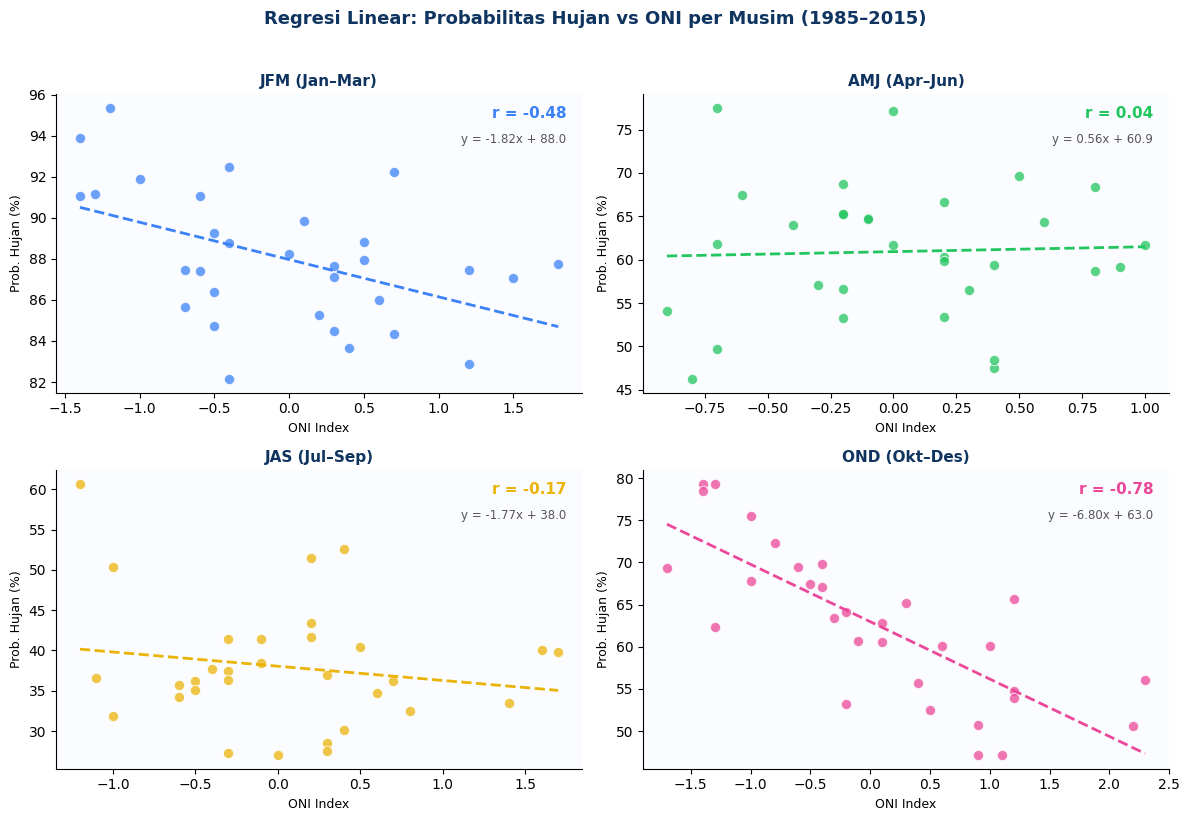

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), facecolor='white')
axes = axes.flatten()  # supaya gampang di-loop

for ax, s in zip(axes, valid_seasons):
    x_data = corr_df[f'ONI_{s}'].values
    y_data = corr_df[f'CH_{s}'].values
    color  = SEASON_COLORS[s]

    mask = ~np.isnan(x_data) & ~np.isnan(y_data)

    ax.scatter(
        x_data[mask],
        y_data[mask],
        color=color,
        alpha=0.75,
        edgecolors='white',
        linewidths=0.8,
        s=55,
        zorder=3
    )

    if mask.sum() > 2:
        coef   = np.polyfit(x_data[mask], y_data[mask], 1)
        x_line = np.linspace(x_data[mask].min(), x_data[mask].max(), 50)
        y_line = np.polyval(coef, x_line)
        r_val  = np.corrcoef(x_data[mask], y_data[mask])[0, 1]

        ax.plot(
            x_line,
            y_line,
            color=color,
            linewidth=2,
            linestyle='--',
            zorder=4
        )

        ax.text(
            0.97, 0.96,
            f'r = {r_val:.2f}',
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=11,
            color=color,
            fontweight='bold'
        )

        ax.text(
            0.97, 0.87,
            f'y = {coef[0]:.2f}x + {coef[1]:.1f}',
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=8.5,
            color='#555'
        )

    ax.set_title(
        f'{s} ({SEASON_MONTHS[s]})',
        fontsize=11,
        fontweight='bold',
        color='#0f3460'
    )

    ax.set_xlabel('ONI Index', fontsize=9)
    ax.set_ylabel('Prob. Hujan (%)', fontsize=9)

    ax.set_facecolor('#fafcff')
    ax.spines[['top', 'right']].set_visible(False)

# Kalau jumlah musim < 4, hapus subplot kosong
for i in range(len(valid_seasons), 4):
    fig.delaxes(axes[i])

fig.suptitle(
    'Regresi Linear: Probabilitas Hujan vs ONI per Musim (1985–2015)',
    fontsize=13,
    fontweight='bold',
    color='#0f3460',
    y=1.02
)

plt.tight_layout()
plt.show()